# Importing Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1:

Importing with os to Just to make it easier for sharing

In [40]:
import os
df = pd.read_csv(os.path.join(os.getcwd(),"sm_risk_data.csv"))

df.head()

,credit_amount,business_age_months,monthly_income_avg,total_deposits_3m,revenue_volatility_3m,request_ratio,dti_monthly,nsf_count_3m,negative_days_3m,owner_percentage,owner_credit_score,p_viable,risk_sharp
0,65119.01,14,31423.29,86800.05,0.745,2.072,0.542,1,3,77.8,571,0.835,0
1,36058.07,94,27885.55,79161.32,0.552,1.293,0.434,3,3,84.4,731,0.918,0
2,9782.59,32,13293.69,42202.89,0.650,0.736,0.432,4,3,81.8,604,0.466,0
3,31340.25,30,18121.27,51841.87,0.726,1.729,0.306,5,7,53.8,729,0.495,1
4,14167.70,32,13954.20,42403.16,0.597,1.015,0.311,3,4,66.7,663,0.608,0


Details of the data 

In [42]:
print("=== Data Types ===")
df.info()


=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   credit_amount          5000 non-null   float64
 1   business_age_months    5000 non-null   int64  
 2   monthly_income_avg     5000 non-null   float64
 3   total_deposits_3m      5000 non-null   float64
 4   revenue_volatility_3m  5000 non-null   float64
 5   request_ratio          5000 non-null   float64
 6   dti_monthly            5000 non-null   float64
 7   nsf_count_3m           5000 non-null   int64  
 8   negative_days_3m       5000 non-null   int64  
 9   owner_percentage       5000 non-null   float64
 10  owner_credit_score     5000 non-null   int64  
 11  p_viable               5000 non-null   float64
 12  risk_sharp             5000 non-null   int64  
dtypes: float64(8), int64(5)
memory usage: 507.9 KB


In [43]:
print("=== Data Summary ===")
df.describe()

=== Data Summary ===


,credit_amount,business_age_months,monthly_income_avg,total_deposits_3m,revenue_volatility_3m,request_ratio,dti_monthly,nsf_count_3m,negative_days_3m,owner_percentage,owner_credit_score,p_viable,risk_sharp
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,19011.238394,44.470000,15359.883066,46079.320594,0.633891,1.261037,0.347414,3.35720,4.555800,69.325800,660.344600,0.573066,0.467800
std,13676.614881,37.769305,9611.460932,29142.597986,0.082129,0.449257,0.151977,1.84377,2.073776,21.211072,59.317022,0.226339,0.499012
min,5000.000000,4.000000,3598.672600,10774.730800,0.355000,0.400000,0.050000,0.00000,1.000000,10.100000,480.000000,0.040000,0.000000
25%,9069.092500,16.000000,8413.295000,24864.920000,0.579750,0.917000,0.232000,2.00000,3.000000,57.300000,621.000000,0.392000,0.000000
50%,14906.270000,30.000000,12762.030000,38215.210000,0.635000,1.165000,0.344000,3.00000,4.000000,71.800000,661.000000,0.567000,0.000000
75%,24370.097500,62.000000,19506.770000,58613.682500,0.691000,1.557000,0.458000,5.00000,6.000000,86.200000,700.000000,0.755000,1.000000
max,65044.000800,144.000000,46340.388600,140030.183600,0.888000,2.499000,0.787000,8.00000,9.000000,100.000000,830.000000,1.000000,1.000000


In [ ]:
print("=== Unique Values & Data Types ===")
print(df.isnull().sum())

credit_amount            0
business_age_months      0
monthly_income_avg       0
total_deposits_3m        0
revenue_volatility_3m    0
request_ratio            0
dti_monthly              0
nsf_count_3m             0
negative_days_3m         0
owner_percentage         0
owner_credit_score       0
p_viable                 0
risk_sharp               0
dtype: int64


In [ ]:
print("=== Unique Values & Data Types ===")
print((df.isnull().sum() / len(df) * 100).round(2))

credit_amount            0.0
business_age_months      0.0
monthly_income_avg       0.0
total_deposits_3m        0.0
revenue_volatility_3m    0.0
request_ratio            0.0
dti_monthly              0.0
nsf_count_3m             0.0
negative_days_3m         0.0
owner_percentage         0.0
owner_credit_score       0.0
p_viable                 0.0
risk_sharp               0.0
dtype: float64


In [45]:
print("=== Unique Values & Data Types ===")
for col in df.columns:
    print(f"'{col}': {df[col].nunique()} unique values | dtype: {df[col].dtype}")

=== Unique Values & Data Types ===
'credit_amount': 4587 unique values | dtype: float64
'business_age_months': 141 unique values | dtype: int64
'monthly_income_avg': 4798 unique values | dtype: float64
'total_deposits_3m': 4799 unique values | dtype: float64
'revenue_volatility_3m': 440 unique values | dtype: float64
'request_ratio': 1635 unique values | dtype: float64
'dti_monthly': 664 unique values | dtype: float64
'nsf_count_3m': 9 unique values | dtype: int64
'negative_days_3m': 9 unique values | dtype: int64
'owner_percentage': 821 unique values | dtype: float64
'owner_credit_score': 329 unique values | dtype: int64
'p_viable': 888 unique values | dtype: float64
'risk_sharp': 2 unique values | dtype: int64


In [31]:
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after drop:", df.shape)

Duplicates found: 0
Shape after drop: (5000, 13)


In [49]:
print("=== Numerical Columns and Categorical Columns ===")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

=== Numerical Columns and Categorical Columns ===
Numerical columns: ['credit_amount', 'business_age_months', 'monthly_income_avg', 'total_deposits_3m', 'revenue_volatility_3m', 'request_ratio', 'dti_monthly', 'nsf_count_3m', 'negative_days_3m', 'owner_percentage', 'owner_credit_score', 'p_viable', 'risk_sharp']
Categorical columns: []


# Step 2: 

Handling the outliers: 
While the outliers here are signal of risk and will be used in upcoming phases will be just be pulled by resanable and small percentage 

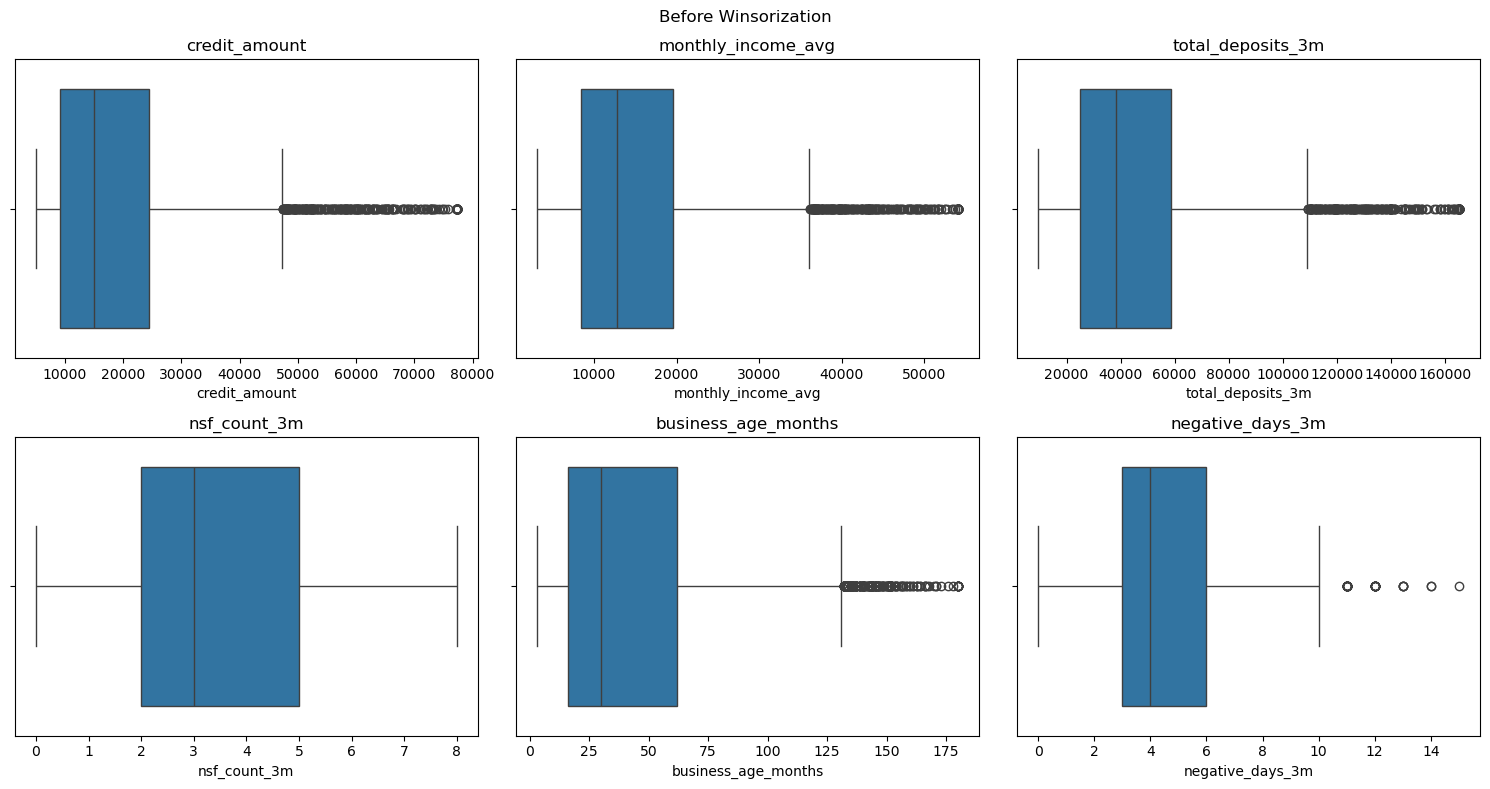

In [34]:
cols_to_winsorize = ['credit_amount', 'monthly_income_avg',
                     'total_deposits_3m', 'nsf_count_3m',
                     'business_age_months', 'negative_days_3m']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols_to_winsorize):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Before Winsorization")
plt.tight_layout()
plt.show()

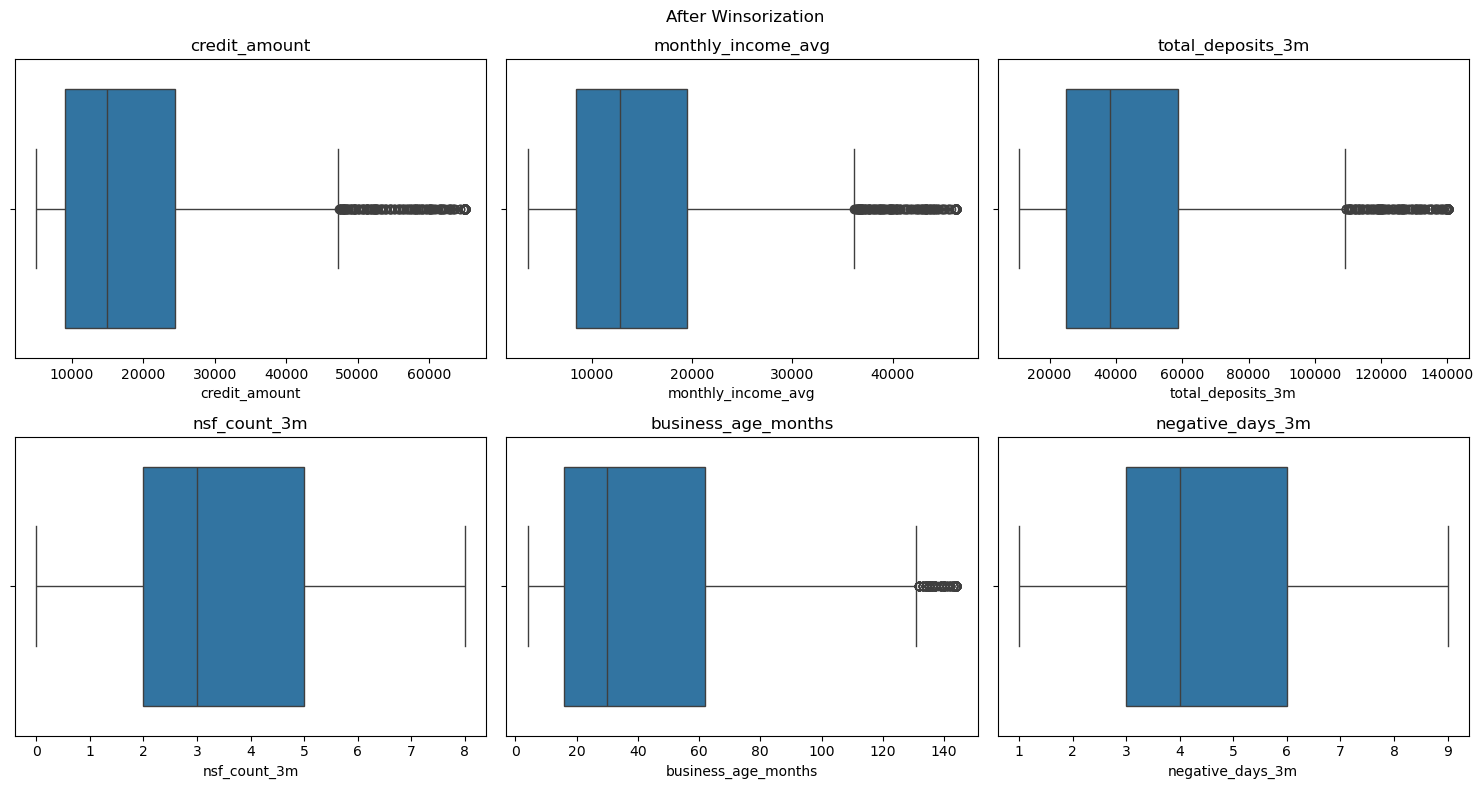

In [41]:
cols_to_winsorize = ['credit_amount', 'monthly_income_avg',
                     'total_deposits_3m', 'nsf_count_3m',
                     'business_age_months', 'negative_days_3m']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols_to_winsorize):
    lower = df[col].quantile(0.02)
    upper = df[col].quantile(0.98)
    df[col] = df[col].clip(lower=lower, upper=upper)
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("After Winsorization")
plt.tight_layout()
plt.show()  

# Step 3: 

Summary

In [50]:
print("=== CLEANING SUMMARY ===")
print(f"Rows: 5000 → {len(df)}")
print(f"Duplicates removed: 0")
print(f"Missing values: 0")
print(f"Columns winsorized: {cols_to_winsorize}")
print(f"Categorical columns encoded: None")
print(f"Final shape: {df.shape}")

=== CLEANING SUMMARY ===
Rows: 5000 → 5000
Duplicates removed: 0
Missing values: 0
Columns winsorized: ['credit_amount', 'monthly_income_avg', 'total_deposits_3m', 'nsf_count_3m', 'business_age_months', 'negative_days_3m']
Categorical columns encoded: None
Final shape: (5000, 13)


In [51]:
df.to_csv('sm_risk_data_cleaned.csv', index=False)
print("✅ Cleaned dataset saved.")

✅ Cleaned dataset saved.
